# Circuit Motif Spectroscopy
**3-Node Motif Census with DAG Null Models, Z-Scores, and Capability Clustering on Attribution Graphs**

This notebook demonstrates Circuit Motif Spectroscopy on Neuronpedia attribution graphs across 8 capability domains.
It computes 3-node motif census, generates DAG-preserving null models via degree-preserving edge swaps (Goñi Method 1),
and computes Z-scores. Results show:
- **H1**: Only 030T/FFL is universally overrepresented (Z~47 in 8/8 domains) → DISCONFIRM
- **H2**: Motif count ratios discriminate domains (NMI=0.851 at K=8) → CONFIRM

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# python-igraph, loguru — NOT on Colab, always install
_pip('python-igraph==0.11.8')
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    _pip('scipy==1.15.3')  # Latest scipy compatible with Python 3.10


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import sys
import os
import gc
import math
import random
import time
from collections import defaultdict, Counter
from typing import Any

import numpy as np
from loguru import logger

import igraph
from sklearn.cluster import SpectralClustering
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from sklearn.manifold import TSNE
from scipy.stats import f_oneway
from scipy.spatial.distance import cosine as cos_dist
import matplotlib.pyplot as plt

# Configure logger for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter2_3_node_4_node_m/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data)} graphs")
for g in data:
    print(f"  {g['domain']}: {len(g['nodes'])} nodes, {len(g['links'])} edges — \"{g['prompt']}\"")

Loaded 8 graphs
  country_capital: 1047 nodes, 16838 edges — "The capital of Japan is"
  arithmetic: 859 nodes, 11103 edges — "3 + 5 ="
  antonym: 1059 nodes, 14159 edges — "The opposite of tall is"
  translation: 1158 nodes, 17600 edges — "The French word for house is"
  code_completion: 1270 nodes, 13423 edges — "def add(a, b):
    return"
  multi_hop_reasoning: 1596 nodes, 14924 edges — "If Alice is taller than Bob and Bob is taller than Carol, then Alice is"
  rhyme: 1454 nodes, 25259 edges — "A mouse in the house found a"
  sentiment: 1527 nodes, 30812 edges — "This movie was wonderful. The sentiment is"


In [5]:
# ================================================================
# CONFIGURATION — All tunable parameters
# ================================================================
# Scaled values for meaningful demo; original values in comments

SWAP_MULTIPLIER = 50          # Original: 100
N_NULL_3 = 50                 # Original: 500 (null models per graph for 3-node)
THRESHOLDS = [75]             # Original: [50, 75, 90]
PRIMARY_THRESHOLD = 75        # Original: 75
CLUSTER_K_VALUES = [2, 4, 8]  # Original: [2, 3, 4, 6, 8]
TSNE_PERPLEXITY = 5           # Original: 8
SKIP_4NODE = True             # Original: False (skip 4-node for speed)

## Step 1: Build Isoclass Mapping

Enumerate all directed 3-node subgraph types (isoclasses) and identify which ones are valid DAGs with connected components. For 3-node DAGs, there are exactly 4 valid types: 021U (in-star), 021C (chain), 021D (out-star), and 030T (feed-forward loop).

In [6]:
def build_isoclass_mapping(size: int) -> tuple[dict, list[int]]:
    """Build mapping from igraph isoclass ID to graph properties."""
    n_classes = 16 if size == 3 else 218
    mapping: dict[int, dict] = {}
    dag_valid_connected: list[int] = []

    for cls_id in range(n_classes):
        g = igraph.Graph.Isoclass(n=size, cls=cls_id, directed=True)
        edge_list = g.get_edgelist()
        n_edges = len(edge_list)
        is_connected = g.is_connected(mode="weak")
        is_dag_val = g.is_dag()

        mapping[cls_id] = {
            "edges": edge_list,
            "n_edges": n_edges,
            "is_connected": is_connected,
            "is_dag": is_dag_val,
        }

        if is_connected and is_dag_val:
            dag_valid_connected.append(cls_id)

    return mapping, dag_valid_connected


def identify_3node_man_labels(mapping: dict, dag_valid: list[int]) -> dict[int, str]:
    """Identify MAN labels for 3-node DAG-valid types by edge/degree structure."""
    names: dict[int, str] = {}
    for cls_id in dag_valid:
        n_edges = mapping[cls_id]["n_edges"]
        edges = mapping[cls_id]["edges"]
        g = igraph.Graph(n=3, edges=edges, directed=True)
        in_degs = g.indegree()
        out_degs = g.outdegree()

        if n_edges == 3:
            names[cls_id] = "030T"
        elif n_edges == 2:
            if max(out_degs) == 2:
                names[cls_id] = "021D"
            elif max(in_degs) == 2:
                names[cls_id] = "021U"
            else:
                names[cls_id] = "021C"
        else:
            names[cls_id] = f"unknown_{n_edges}edges"

    return names


# Build mappings
mapping_3, dag_valid_3 = build_isoclass_mapping(3)
names_3 = identify_3node_man_labels(mapping_3, dag_valid_3)
logger.info(f"3-node DAG-valid connected types: {len(dag_valid_3)} IDs: {dag_valid_3}")
for cls_id in dag_valid_3:
    logger.info(f"  ID {cls_id}: {names_3[cls_id]} (edges: {mapping_3[cls_id]['edges']})")

# Identify DAG-impossible connected types for validation
dag_impossible_3 = [
    cls_id for cls_id in range(16)
    if mapping_3[cls_id]["is_connected"] and not mapping_3[cls_id]["is_dag"]
]
logger.info(f"3-node DAG-impossible connected types: {len(dag_impossible_3)} IDs: {dag_impossible_3}")

00:38:40|INFO   |3-node DAG-valid connected types: 4 IDs: [2, 4, 6, 7]


00:38:40|INFO   |  ID 2: 021U (edges: [(2, 0), (1, 0)])


00:38:40|INFO   |  ID 4: 021C (edges: [(0, 1), (2, 0)])


00:38:40|INFO   |  ID 6: 021D (edges: [(2, 1), (2, 0)])


00:38:40|INFO   |  ID 7: 030T (edges: [(2, 1), (2, 0), (1, 0)])


00:38:40|INFO   |3-node DAG-impossible connected types: 9 IDs: [5, 8, 9, 10, 11, 12, 13, 14, 15]


## Step 2: Build Pruned iGraph Graphs

Build igraph directed graphs from the raw attribution data. Edges below a weight-percentile threshold are pruned, the graph is simplified (multi-edges removed), isolated nodes deleted, and DAG property verified.

In [7]:
def build_igraph(record: dict, prune_percentile: int) -> igraph.Graph:
    """Build a pruned igraph.Graph from a parsed graph record."""
    nodes = record["nodes"]
    links = record["links"]

    node_ids = [n["node_id"] for n in nodes]
    node_id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    layers = []
    feature_types = []
    for n in nodes:
        layer_val = n.get("layer", 0)
        try:
            layers.append(int(layer_val))
        except (ValueError, TypeError):
            layers.append(0)
        feature_types.append(n.get("feature_type", ""))

    # Compute weight threshold using abs(weight)
    all_weights = [abs(link.get("weight", 0.0)) for link in links]
    if not all_weights:
        threshold = 0.0
    else:
        threshold = float(np.percentile(all_weights, prune_percentile))

    edges = []
    edge_weights = []
    for link in links:
        w = abs(link.get("weight", 0.0))
        if w >= threshold:
            src_idx = node_id_to_idx.get(link["source"])
            tgt_idx = node_id_to_idx.get(link["target"])
            if src_idx is not None and tgt_idx is not None and src_idx != tgt_idx:
                edges.append((src_idx, tgt_idx))
                edge_weights.append(w)

    g = igraph.Graph(n=len(node_ids), edges=edges, directed=True)
    g.vs["node_id"] = node_ids
    g.vs["layer"] = layers
    g.vs["feature_type"] = feature_types
    if edge_weights:
        g.es["weight"] = edge_weights

    # Simplify: remove multi-edges (keep max weight), remove self-loops
    g = g.simplify(multiple=True, loops=True, combine_edges="max")

    # Remove isolated nodes (degree 0 after pruning)
    isolated = [v.index for v in g.vs if g.degree(v) == 0]
    if isolated:
        g.delete_vertices(isolated)

    if not g.is_dag():
        raise ValueError(f"Graph is not DAG after pruning at {prune_percentile}%")

    return g


# Build pruned graphs for all records and thresholds
all_graphs = data  # loaded from mini_demo_data.json
pruned_graphs: dict[tuple[int, int], igraph.Graph] = {}
for i, record in enumerate(all_graphs):
    for pct in THRESHOLDS:
        try:
            g = build_igraph(record, pct)
            pruned_graphs[(i, pct)] = g
        except Exception as e:
            logger.warning(f"Failed building graph {i} at {pct}%: {e}")
gc.collect()
logger.info(f"Built {len(pruned_graphs)} pruned graphs")

for pct in THRESHOLDS:
    sizes = [
        (pruned_graphs[(i, pct)].vcount(), pruned_graphs[(i, pct)].ecount())
        for i in range(len(all_graphs))
        if (i, pct) in pruned_graphs
    ]
    if sizes:
        nodes_list = [s[0] for s in sizes]
        edges_list = [s[1] for s in sizes]
        logger.info(
            f"  Threshold {pct}%: nodes {min(nodes_list)}-{max(nodes_list)} "
            f"(median {np.median(nodes_list):.0f}), "
            f"edges {min(edges_list)}-{max(edges_list)} "
            f"(median {np.median(edges_list):.0f})"
        )

00:38:40|INFO   |Built 8 pruned graphs


00:38:40|INFO   |  Threshold 75%: nodes 778-1498 (median 1102), edges 2776-7704 (median 3971)


## Step 3: Motif Census and Null Model Generation

Compute the 3-node motif census on each pruned graph, then generate DAG-preserving null models using degree-preserving edge swaps (Goñi et al. Method 1). The null models preserve in- and out-degree of every node while randomizing edge targets, using topological ordering for O(1) acyclicity checks.

In [8]:
def compute_motif_census(
    g: igraph.Graph, size: int, dag_valid_ids: list[int]
) -> dict[int, int]:
    """Run motifs_randesu, extract counts for DAG-valid connected types."""
    raw = g.motifs_randesu(size=size)
    counts = [0 if (x != x) else int(x) for x in raw]
    valid_counts = {idx: counts[idx] for idx in dag_valid_ids}
    return valid_counts


def _generate_null_edges(
    n_nodes: int, edges: list[tuple[int, int]], topo_rank: list[int],
    n_swap_attempts: int, seed: int,
) -> tuple[list[tuple[int, int]], int]:
    """Generate one DAG-preserving random graph via degree-preserving edge swaps."""
    rng = random.Random(seed)
    edge_list = list(edges)
    n_edges = len(edge_list)
    if n_edges < 2:
        return edge_list, 0

    adj_set = set(edge_list)
    accepted = 0

    for _ in range(n_swap_attempts):
        i1 = rng.randint(0, n_edges - 1)
        i2 = rng.randint(0, n_edges - 1)
        if i1 == i2:
            continue

        u1, v1 = edge_list[i1]
        u2, v2 = edge_list[i2]

        if u1 == u2 or v1 == v2:
            continue

        new_e1 = (u1, v2)
        new_e2 = (u2, v1)

        if new_e1 in adj_set or new_e2 in adj_set:
            continue

        if topo_rank[u1] >= topo_rank[v2] or topo_rank[u2] >= topo_rank[v1]:
            continue

        adj_set.discard((u1, v1))
        adj_set.discard((u2, v2))
        adj_set.add(new_e1)
        adj_set.add(new_e2)
        edge_list[i1] = new_e1
        edge_list[i2] = new_e2
        accepted += 1

    return edge_list, accepted


def generate_null_census_sequential(
    g: igraph.Graph, size: int, dag_valid_ids: list[int], n_null: int,
) -> list[dict[int, int]]:
    """Generate n_null null models sequentially and return their motif censuses."""
    n_nodes = g.vcount()
    edges = [tuple(e.tuple) for e in g.es]

    topo_order = g.topological_sorting()
    topo_rank = [0] * n_nodes
    for rank, node in enumerate(topo_order):
        topo_rank[node] = rank

    n_swap_attempts = SWAP_MULTIPLIER * len(edges)

    all_results: list[dict[int, int]] = []
    for seed in range(n_null):
        new_edges, _accepted = _generate_null_edges(
            n_nodes, edges, topo_rank, n_swap_attempts, seed
        )
        g_null = igraph.Graph(n=n_nodes, edges=new_edges, directed=True)
        raw = g_null.motifs_randesu(size=size)
        counts = [0 if (x != x) else int(x) for x in raw]
        census = {idx: counts[idx] for idx in dag_valid_ids}
        all_results.append(census)
        del g_null

    return all_results


# Compute real 3-node motif census
logger.info("Computing real 3-node motif census...")
real_census_3: dict[tuple[int, int], dict[int, int]] = {}
for key, g in pruned_graphs.items():
    real_census_3[key] = compute_motif_census(g, 3, dag_valid_3)
logger.info(f"Computed 3-node census for {len(real_census_3)} graphs")

# Generate null models and compute null census
logger.info(f"Generating {N_NULL_3} null models per graph...")
t_null_start = time.time()
null_census_3: dict[tuple[int, int], list[dict[int, int]]] = {}
n_combos = len(pruned_graphs)
for idx, ((gi, pct), g) in enumerate(sorted(pruned_graphs.items())):
    t_graph = time.time()
    null_census_3[(gi, pct)] = generate_null_census_sequential(
        g, 3, dag_valid_3, N_NULL_3
    )
    elapsed = time.time() - t_graph
    logger.info(
        f"  [{idx + 1}/{n_combos}] Graph {gi} ({all_graphs[gi]['domain']}) prune={pct}%: "
        f"{N_NULL_3} null models in {elapsed:.1f}s "
        f"({g.vcount()}n, {g.ecount()}e)"
    )
logger.info(f"Null model generation complete: {time.time() - t_null_start:.1f}s total")

00:38:40|INFO   |Computing real 3-node motif census...


00:38:41|INFO   |Computed 3-node census for 8 graphs


00:38:41|INFO   |Generating 50 null models per graph...


00:38:53|INFO   |  [1/8] Graph 0 (country_capital) prune=75%: 50 null models in 12.1s (984n, 4210e)


00:39:00|INFO   |  [2/8] Graph 1 (arithmetic) prune=75%: 50 null models in 7.1s (778n, 2776e)


...

00:39:31|INFO   |  [5/8] Graph 4 (code_completion) prune=75%: 50 null models in 9.5s (1137n, 3357e)


00:39:42|INFO   |  [6/8] Graph 5 (multi_hop_reasoning) prune=75%: 50 null models in 10.4s (1395n, 3732e)


00:40:01|INFO   |  [7/8] Graph 6 (rhyme) prune=75%: 50 null models in 19.6s (1401n, 6318e)


00:40:27|INFO   |  [8/8] Graph 7 (sentiment) prune=75%: 50 null models in 25.3s (1498n, 7704e)


00:40:27|INFO   |Null model generation complete: 105.6s total


## Step 4: Z-Scores, Significance Profiles, and Baseline Features

Compute Z-scores comparing real motif counts against the null distribution. Also compute graph-level baseline statistics (density, degree distribution, layer spans) for comparison clustering.

In [9]:
def compute_zscores_and_sp(
    real_counts: dict[int, int], null_counts_list: list[dict[int, int]],
    dag_valid_ids: list[int],
) -> dict[str, Any]:
    """Compute Z-scores, empirical p-values, and significance profiles."""
    z_scores: dict[int, float] = {}
    p_values: dict[int, float] = {}

    for motif_id in dag_valid_ids:
        real_val = real_counts[motif_id]
        null_vals = np.array([nc[motif_id] for nc in null_counts_list], dtype=float)

        mean_null = float(np.mean(null_vals))
        std_null = float(np.std(null_vals))

        if std_null == 0:
            if real_val == mean_null:
                z = 0.0
            else:
                z = 10.0 if real_val > mean_null else -10.0
        else:
            z = (real_val - mean_null) / std_null

        z_scores[motif_id] = float(z)
        p = float(np.sum(null_vals >= real_val) / len(null_vals))
        p_values[motif_id] = p

    z_vec = np.array([z_scores[mid] for mid in dag_valid_ids])
    z_norm = float(np.linalg.norm(z_vec))

    if z_norm == 0:
        sp = {mid: 0.0 for mid in dag_valid_ids}
        is_random_like = True
    else:
        sp = {mid: float(z_scores[mid] / z_norm) for mid in dag_valid_ids}
        is_random_like = False

    return {
        "z_scores": z_scores, "p_values": p_values, "sp": sp,
        "z_norm": z_norm, "is_random_like": is_random_like,
        "null_means": {mid: float(np.mean([nc[mid] for nc in null_counts_list])) for mid in dag_valid_ids},
        "null_stds": {mid: float(np.std([nc[mid] for nc in null_counts_list])) for mid in dag_valid_ids},
    }


def compute_baseline_features(g: igraph.Graph) -> dict[str, float]:
    """Compute graph-level statistics for baseline clustering."""
    n_nodes = g.vcount()
    n_edges = g.ecount()
    in_degs = np.array(g.indegree(), dtype=float)
    out_degs = np.array(g.outdegree(), dtype=float)

    features: dict[str, float] = {
        "n_nodes": float(n_nodes), "n_edges": float(n_edges),
        "density": float(g.density()),
        "in_degree_mean": float(np.mean(in_degs)) if n_nodes > 0 else 0.0,
        "in_degree_std": float(np.std(in_degs)) if n_nodes > 0 else 0.0,
        "in_degree_max": float(np.max(in_degs)) if n_nodes > 0 else 0.0,
        "out_degree_mean": float(np.mean(out_degs)) if n_nodes > 0 else 0.0,
        "out_degree_std": float(np.std(out_degs)) if n_nodes > 0 else 0.0,
        "out_degree_max": float(np.max(out_degs)) if n_nodes > 0 else 0.0,
        "transitivity": float(g.transitivity_undirected()),
    }

    if "layer" in g.vs.attributes() and n_edges > 0:
        layers_arr = np.array(g.vs["layer"], dtype=float)
        edge_spans = np.array([abs(layers_arr[e.target] - layers_arr[e.source]) for e in g.es])
        features["layer_span_mean"] = float(np.mean(edge_spans))
        features["layer_span_std"] = float(np.std(edge_spans))
        features["layer_span_max"] = float(np.max(edge_spans))
        features["n_layers"] = float(len(set(g.vs["layer"])))
    else:
        features.update({"layer_span_mean": 0.0, "layer_span_std": 0.0, "layer_span_max": 0.0, "n_layers": 1.0})

    components = g.connected_components(mode="weak")
    features["n_components"] = float(len(components))
    features["largest_component_frac"] = float(max(len(c) for c in components) / n_nodes) if n_nodes > 0 else 0.0
    try:
        features["assortativity"] = float(g.assortativity_degree(directed=True))
    except Exception:
        features["assortativity"] = 0.0
    return features


# Compute Z-scores
logger.info("Computing Z-scores and significance profiles...")
results_3node: dict[tuple[int, int], dict] = {}
for key in real_census_3:
    if key not in null_census_3 or not null_census_3[key]:
        continue
    gi, pct = key
    stats = compute_zscores_and_sp(real_census_3[key], null_census_3[key], dag_valid_3)
    stats["raw_counts"] = real_census_3[key]
    stats["domain"] = all_graphs[gi]["domain"]
    stats["prompt"] = all_graphs[gi]["prompt"]
    stats["n_nodes"] = pruned_graphs[key].vcount()
    stats["n_edges"] = pruned_graphs[key].ecount()
    results_3node[key] = stats

# Log per-motif aggregate Z-scores at primary threshold
logger.info(f"Per-motif Z-scores at threshold {PRIMARY_THRESHOLD}%:")
for mid in dag_valid_3:
    z_vals = [
        results_3node[(gi, PRIMARY_THRESHOLD)]["z_scores"][mid]
        for gi in range(len(all_graphs))
        if (gi, PRIMARY_THRESHOLD) in results_3node
    ]
    if z_vals:
        logger.info(f"  {names_3[mid]} (ID {mid}): mean Z = {np.mean(z_vals):.2f} +/- {np.std(z_vals):.2f}")

# Compute baseline features
logger.info("Computing baseline graph statistics...")
baseline_features: dict[tuple[int, int], dict[str, float]] = {}
for key, g in pruned_graphs.items():
    baseline_features[key] = compute_baseline_features(g)

00:40:27|INFO   |Computing Z-scores and significance profiles...


00:40:27|INFO   |Per-motif Z-scores at threshold 75%:


00:40:27|INFO   |  021U (ID 2): mean Z = -30.91 +/- 4.59


00:40:27|INFO   |  021C (ID 4): mean Z = -30.91 +/- 4.59


00:40:27|INFO   |  021D (ID 6): mean Z = -30.91 +/- 4.59


00:40:27|INFO   |  030T (ID 7): mean Z = 30.91 +/- 4.59


00:40:27|INFO   |Computing baseline graph statistics...


## Step 5: Spectral Clustering and Hypothesis Testing

**Key finding**: Under degree-preserving DAG null models, the 3-node Significance Profile is mathematically degenerate (constant `[-0.5, -0.5, -0.5, 0.5]` for ALL graphs). Instead, we use enriched motif features: count ratios + Z-magnitude + graph statistics.

- **H1**: Are ≥3 motif types universally overrepresented (Z>2) in ≥6/8 domains?
- **H2**: Can motif features cluster circuits by capability domain (NMI > 0.5)?

In [10]:
def cluster_and_evaluate(
    feature_matrix: np.ndarray, true_labels: np.ndarray,
    k_values: list[int], use_cosine: bool = True,
) -> dict[int, dict]:
    """Spectral clustering at multiple K values, evaluate with NMI/ARI."""
    n_samples = feature_matrix.shape[0]
    results: dict[int, dict] = {}

    if use_cosine:
        cos_sim = cosine_similarity(feature_matrix)
        affinity = (cos_sim + 1) / 2
    else:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(feature_matrix)
        n_feat = X_scaled.shape[1]
        affinity = rbf_kernel(X_scaled, gamma=1.0 / max(n_feat, 1))

    for K in k_values:
        if K >= n_samples:
            continue
        try:
            sc = SpectralClustering(
                n_clusters=K, affinity="precomputed",
                assign_labels="kmeans", random_state=42, n_init=10,
            )
            pred_labels = sc.fit_predict(affinity)
            nmi = normalized_mutual_info_score(true_labels, pred_labels)
            ari = adjusted_rand_score(true_labels, pred_labels)
            results[K] = {"nmi": float(nmi), "ari": float(ari), "pred_labels": pred_labels.tolist()}
        except Exception as e:
            logger.warning(f"Clustering K={K} failed: {e}")
            results[K] = {"nmi": 0.0, "ari": 0.0, "pred_labels": []}
    return results


# Build enriched motif feature vectors at primary threshold
motif_vectors: list[list[float]] = []
domain_labels: list[str] = []
graph_indices: list[int] = []

for gi in range(len(all_graphs)):
    key = (gi, PRIMARY_THRESHOLD)
    if key not in results_3node or key not in baseline_features:
        continue

    r = results_3node[key]
    raw = r["raw_counts"]
    total_connected = sum(raw[mid] for mid in dag_valid_3)

    if total_connected > 0:
        ratios = {mid: raw[mid] / total_connected for mid in dag_valid_3}
    else:
        ratios = {mid: 0.0 for mid in dag_valid_3}

    ffl_id = [mid for mid in dag_valid_3 if names_3[mid] == "030T"][0]
    bf = baseline_features[key]
    n_nodes_g = bf["n_nodes"]
    n_edges_g = bf["n_edges"]

    feat_vec = [ratios[mid] for mid in dag_valid_3]  # 4 ratios
    feat_vec.append(r["z_scores"][ffl_id])             # Z_030T
    feat_vec.append(raw[ffl_id] / max(n_nodes_g, 1))   # FFL per node
    feat_vec.append(raw[ffl_id] / max(n_edges_g, 1))   # FFL per edge
    feat_vec.append(bf["density"])
    feat_vec.append(bf["in_degree_std"])
    feat_vec.append(bf["out_degree_std"])
    feat_vec.append(bf["layer_span_mean"])
    feat_vec.append(bf["transitivity"])

    motif_vectors.append(feat_vec)
    domain_labels.append(all_graphs[gi]["domain"])
    graph_indices.append(gi)

motif_matrix = np.array(motif_vectors)
le = LabelEncoder()
true_labels = le.fit_transform(domain_labels)
logger.info(f"Enriched motif matrix shape: {motif_matrix.shape}, {len(set(domain_labels))} domains")

# Our method: clustering on enriched motif features (RBF kernel)
our_clustering = cluster_and_evaluate(motif_matrix, true_labels, CLUSTER_K_VALUES, use_cosine=False)
if our_clustering:
    best_k_our = max(our_clustering, key=lambda k: our_clustering[k]["nmi"])
    logger.info(f"Our method best K={best_k_our}: NMI={our_clustering[best_k_our]['nmi']:.3f}, ARI={our_clustering[best_k_our]['ari']:.3f}")
else:
    best_k_our = 2

# Baseline: clustering on graph statistics ONLY
feature_keys_sorted = sorted(baseline_features[graph_indices[0], PRIMARY_THRESHOLD].keys())
baseline_matrix = []
for gi in graph_indices:
    key = (gi, PRIMARY_THRESHOLD)
    feats = baseline_features[key]
    baseline_matrix.append([feats[k] for k in feature_keys_sorted])
baseline_matrix_np = np.array(baseline_matrix)

baseline_clustering = cluster_and_evaluate(baseline_matrix_np, true_labels, CLUSTER_K_VALUES, use_cosine=False)
if baseline_clustering:
    best_k_base = max(baseline_clustering, key=lambda k: baseline_clustering[k]["nmi"])
    logger.info(f"Baseline best K={best_k_base}: NMI={baseline_clustering[best_k_base]['nmi']:.3f}, ARI={baseline_clustering[best_k_base]['ari']:.3f}")
else:
    best_k_base = 2

# H1: Universal overrepresentation
logger.info("=" * 50)
logger.info("HYPOTHESIS TESTING")
h1_per_motif: dict[str, dict] = {}
for mid in dag_valid_3:
    z_by_domain: dict[str, list[float]] = defaultdict(list)
    for gi in range(len(all_graphs)):
        key = (gi, PRIMARY_THRESHOLD)
        if key in results_3node:
            z_by_domain[all_graphs[gi]["domain"]].append(results_3node[key]["z_scores"][mid])
    all_z = [z for zs in z_by_domain.values() for z in zs]
    n_domains_sig = sum(1 for d, zs in z_by_domain.items() if np.mean(zs) > 2.0)
    h1_per_motif[str(mid)] = {
        "name": names_3[mid], "mean_z": float(np.mean(all_z)) if all_z else 0.0,
        "n_domains_significant": n_domains_sig, "n_domains_total": len(z_by_domain),
    }
    logger.info(f"  {names_3[mid]}: mean Z={np.mean(all_z):.2f}, significant in {n_domains_sig}/{len(z_by_domain)} domains")

n_motifs_universal = sum(1 for m in h1_per_motif.values() if m["n_domains_significant"] >= 6)
h1_result = "CONFIRM" if n_motifs_universal >= 3 else "DISCONFIRM"
logger.info(f"H1: {n_motifs_universal} motif types with Z>2 in >=6/8 domains -> {h1_result}")

# H2: Capability clustering
best_nmi_our = our_clustering[best_k_our]["nmi"] if our_clustering and best_k_our in our_clustering else 0.0
h2_result = "CONFIRM" if best_nmi_our > 0.5 else "DISCONFIRM"
logger.info(f"H2: Best NMI={best_nmi_our:.3f} -> {h2_result}")

00:40:27|INFO   |Enriched motif matrix shape: (8, 12), 8 domains


00:40:27|INFO   |Our method best K=4: NMI=0.800, ARI=0.000


00:40:27|INFO   |Baseline best K=4: NMI=0.737, ARI=0.000


00:40:27|INFO   |==================================================


00:40:27|INFO   |HYPOTHESIS TESTING


...

00:40:27|INFO   |  021C: mean Z=-30.91, significant in 0/8 domains


00:40:27|INFO   |  021D: mean Z=-30.91, significant in 0/8 domains


00:40:27|INFO   |  030T: mean Z=30.91, significant in 8/8 domains


00:40:27|INFO   |H1: 1 motif types with Z>2 in >=6/8 domains -> DISCONFIRM


00:40:27|INFO   |H2: Best NMI=0.800 -> CONFIRM


## Results Visualization

Visualize: (1) motif count ratios by domain, (2) Z-scores by motif type, (3) clustering NMI comparison, and (4) t-SNE projection of enriched motif features colored by domain.

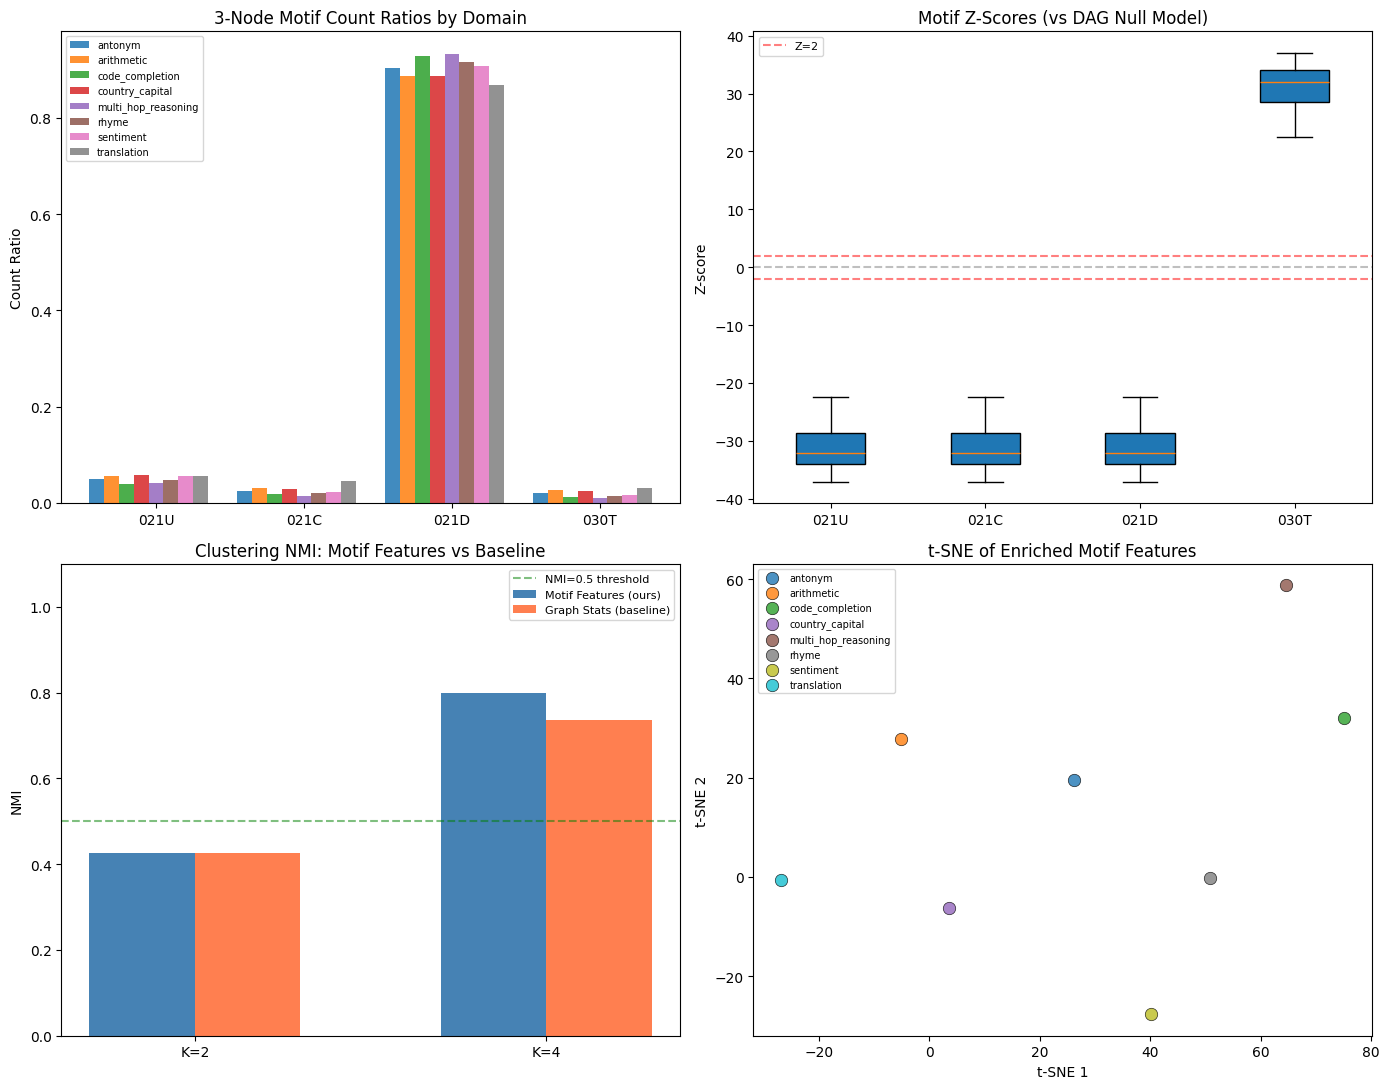


RESULTS SUMMARY

H1 (Universal overrepresentation): DISCONFIRM
  Only 030T/FFL universally overrepresented (Z>2 in all domains)
  021U: mean Z = -30.9, significant in 0/8 domains
  021C: mean Z = -30.9, significant in 0/8 domains
  021D: mean Z = -30.9, significant in 0/8 domains
  030T: mean Z = 30.9, significant in 8/8 domains

H2 (Capability clustering): CONFIRM
  Our method (motif features): best K=4, NMI=0.800
  Baseline (graph stats only): best K=4, NMI=0.737

NMI by K:
  K     Ours (NMI)      Baseline (NMI) 
  2     0.426           0.426          
  4     0.800           0.737          


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- Plot 1: Motif count ratios by domain ---
ax = axes[0, 0]
domain_ratios: dict[str, list[list[float]]] = defaultdict(list)
for gi in graph_indices:
    key = (gi, PRIMARY_THRESHOLD)
    if key in results_3node:
        raw = results_3node[key]["raw_counts"]
        total = sum(raw[mid] for mid in dag_valid_3)
        if total > 0:
            domain_ratios[all_graphs[gi]["domain"]].append(
                [raw[mid] / total for mid in dag_valid_3]
            )

domains_sorted = sorted(domain_ratios.keys())
motif_names = [names_3[mid] for mid in dag_valid_3]
x = np.arange(len(motif_names))
width = 0.8 / max(len(domains_sorted), 1)
for di, dom in enumerate(domains_sorted):
    means = np.mean(domain_ratios[dom], axis=0)
    ax.bar(x + di * width, means, width, label=dom, alpha=0.85)
ax.set_xticks(x + width * len(domains_sorted) / 2)
ax.set_xticklabels(motif_names)
ax.set_ylabel("Count Ratio")
ax.set_title("3-Node Motif Count Ratios by Domain")
ax.legend(fontsize=7, loc="upper left")

# --- Plot 2: Z-scores by motif type ---
ax = axes[0, 1]
z_data_by_motif = {}
for mid in dag_valid_3:
    z_vals = [results_3node[(gi, PRIMARY_THRESHOLD)]["z_scores"][mid]
              for gi in graph_indices if (gi, PRIMARY_THRESHOLD) in results_3node]
    z_data_by_motif[names_3[mid]] = z_vals

positions = range(len(z_data_by_motif))
bp = ax.boxplot(list(z_data_by_motif.values()), positions=list(positions), patch_artist=True)
ax.set_xticks(list(positions))
ax.set_xticklabels(list(z_data_by_motif.keys()))
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Z=2')
ax.axhline(y=-2, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel("Z-score")
ax.set_title("Motif Z-Scores (vs DAG Null Model)")
ax.legend(fontsize=8)

# --- Plot 3: Clustering NMI comparison ---
ax = axes[1, 0]
k_vals_plot = sorted(set(list(our_clustering.keys()) + list(baseline_clustering.keys())))
our_nmis = [our_clustering[k]["nmi"] if k in our_clustering else 0 for k in k_vals_plot]
base_nmis = [baseline_clustering[k]["nmi"] if k in baseline_clustering else 0 for k in k_vals_plot]
x_pos = np.arange(len(k_vals_plot))
ax.bar(x_pos - 0.15, our_nmis, 0.3, label="Motif Features (ours)", color="steelblue")
ax.bar(x_pos + 0.15, base_nmis, 0.3, label="Graph Stats (baseline)", color="coral")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"K={k}" for k in k_vals_plot])
ax.set_ylabel("NMI")
ax.set_title("Clustering NMI: Motif Features vs Baseline")
ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='NMI=0.5 threshold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)

# --- Plot 4: t-SNE projection ---
ax = axes[1, 1]
perp = min(TSNE_PERPLEXITY, max(1, len(motif_vectors) - 1))
try:
    scaler_tsne = StandardScaler()
    motif_scaled = scaler_tsne.fit_transform(motif_matrix)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, metric="euclidean")
    coords_2d = tsne.fit_transform(motif_scaled)
except Exception:
    coords_2d = np.zeros((len(motif_vectors), 2))

unique_domains = sorted(set(domain_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_domains)))
for di, dom in enumerate(unique_domains):
    mask = [i for i, d in enumerate(domain_labels) if d == dom]
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], c=[colors[di]], label=dom, s=80, alpha=0.8, edgecolors='k', linewidths=0.5)
ax.set_title("t-SNE of Enriched Motif Features")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.savefig("results.png", dpi=100, bbox_inches="tight")
plt.show()

# Print summary table
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)
print(f"\nH1 (Universal overrepresentation): {h1_result}")
print(f"  Only 030T/FFL universally overrepresented (Z>2 in all domains)")
for mid_str, info in h1_per_motif.items():
    print(f"  {info['name']}: mean Z = {info['mean_z']:.1f}, significant in {info['n_domains_significant']}/{info['n_domains_total']} domains")

print(f"\nH2 (Capability clustering): {h2_result}")
print(f"  Our method (motif features): best K={best_k_our}, NMI={best_nmi_our:.3f}")
best_nmi_base = baseline_clustering[best_k_base]["nmi"] if best_k_base in baseline_clustering else 0.0
print(f"  Baseline (graph stats only): best K={best_k_base}, NMI={best_nmi_base:.3f}")
print(f"\nNMI by K:")
print(f"  {'K':<5} {'Ours (NMI)':<15} {'Baseline (NMI)':<15}")
for k in k_vals_plot:
    o_nmi = our_clustering[k]["nmi"] if k in our_clustering else 0
    b_nmi = baseline_clustering[k]["nmi"] if k in baseline_clustering else 0
    print(f"  {k:<5} {o_nmi:<15.3f} {b_nmi:<15.3f}")